# Thesis figures - editable playground

Every thesis figure in one place. **Run the two setup cells first**, then any
figure cell independently. Each `save(fig, "name")` writes the PDF + PNG to
`docs/thesis/figures/` and copies the PDF into `docs/thesis/wut/tex/img/`
(what the LaTeX uses), so a rerun here updates the thesis directly.

Style knobs live in the setup cell (`STYLE`, colors). Per-figure knobs
(sizes, labels, colors) are at the top of each cell. The canonical scripts
`scripts/generate_thesis_assets.py` and `scripts/generate_extra_figures.py`
remain the source of truth for reproducibility - if you settle on changes
here, mirror them there (or ask Claude to).

In [1]:
# ---- Setup: paths, style, save helper (RUN FIRST) ----
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "scripts").exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
RESULTS = PROJECT_ROOT / "results"
FIGDIR = PROJECT_ROOT / "docs" / "thesis" / "figures"
IMGDIR = PROJECT_ROOT / "docs" / "thesis" / "wut" / "tex" / "img"

# Global style: thick lines, large fonts (supervisor feedback)
STYLE = {
    "figure.dpi": 150, "font.size": 14, "axes.grid": True,
    "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelsize": 15, "xtick.labelsize": 13, "ytick.labelsize": 13,
    "legend.fontsize": 12, "lines.linewidth": 2.5, "lines.markersize": 8,
    "axes.linewidth": 1.2,
}
plt.rcParams.update(STYLE)

# Semantic palette: green = good, red = bad, grey = neutral
GOOD, BAD, NEUT = "#2e7d32", "#c62828", "#9e9e9e"
BLUE, ORANGE, GRAY = "#1565c0", "#e65100", "#9e9e9e"

def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGDIR / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(FIGDIR / f"{name}.png", dpi=200, bbox_inches="tight")
    shutil.copy(FIGDIR / f"{name}.pdf", IMGDIR / f"{name}.pdf")
    print(f"saved {name} -> figures/ + wut/tex/img/")

print("project root:", PROJECT_ROOT)

project root: C:\Users\ewenl\draft-koko


In [2]:
# ---- Load the small data every figure draws on (RUN SECOND) ----
mbti = pd.read_csv(DATA_DIR / "raw" / "mbti_1.csv")
mbti["type"] = mbti["type"].str.upper()

biz = pd.read_parquet(DATA_DIR / "processed" / "businesses.parquet")

agg = pd.read_csv(RESULTS / "phase4_robustness_agg.csv")
per_seed = pd.read_csv(RESULTS / "phase4_robustness_per_seed.csv")
faith = pd.read_csv(RESULTS / "faithfulness_eval.csv")
print("loaded: mbti", mbti.shape, "| biz", biz.shape,
      "| agg", agg.shape, "| per_seed", per_seed.shape)

loaded: mbti (8675, 2) | biz (92140, 14) | agg (24, 12) | per_seed (120, 8)


## Chapter 3 - dataset figures

saved fig_mbti_type_dist -> figures/ + wut/tex/img/


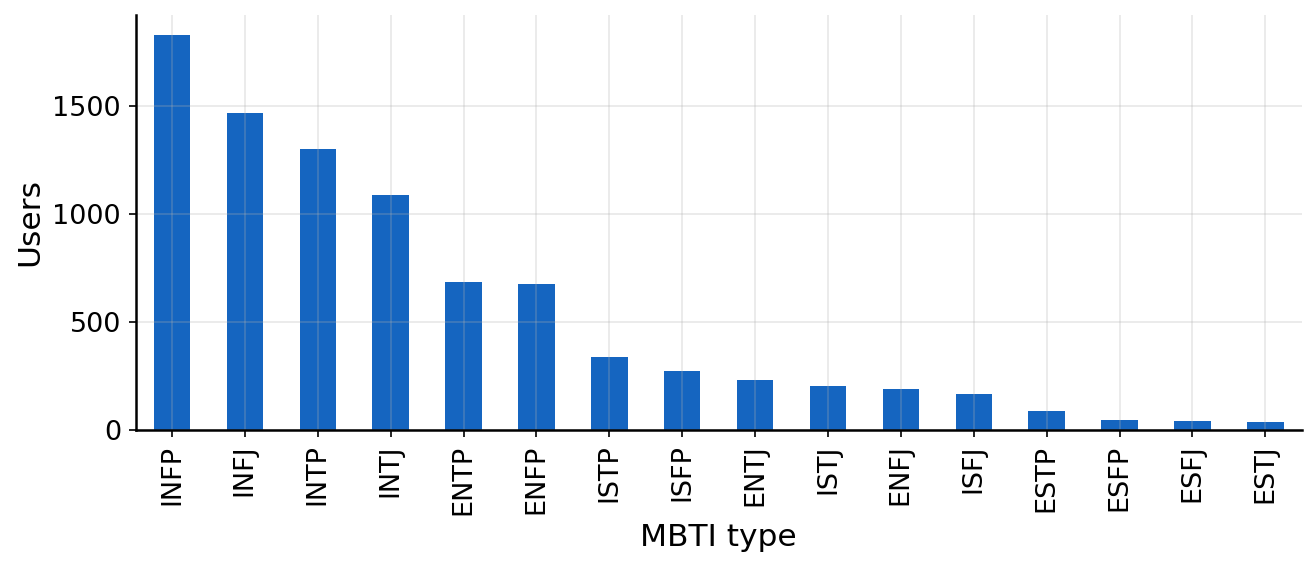

In [3]:
# ---- fig_mbti_type_dist: users per 16-type ----
counts = mbti["type"].value_counts()
fig, ax = plt.subplots(figsize=(9, 4))
counts.plot.bar(ax=ax, color=BLUE)
ax.set_ylabel("Users")
ax.set_xlabel("MBTI type")
save(fig, "fig_mbti_type_dist")

saved fig_mbti_axis_balance -> figures/ + wut/tex/img/


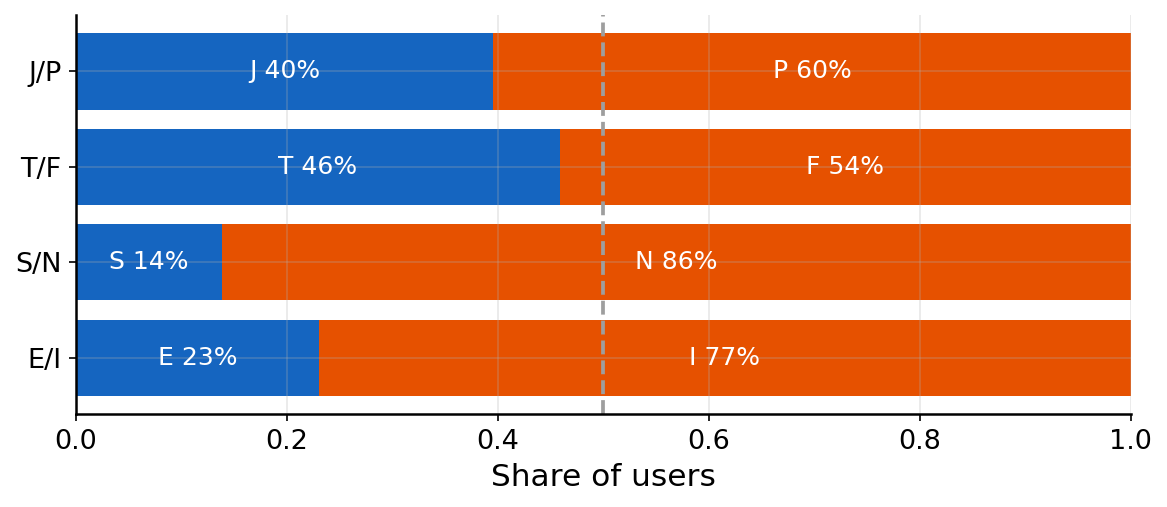

In [4]:
# ---- fig_mbti_axis_balance: per-axis class shares ----
axes_def = [("E", "I", 0), ("S", "N", 1), ("T", "F", 2), ("J", "P", 3)]
fig, ax = plt.subplots(figsize=(8, 3.6))
labels, first_frac = [], []
for a, b, pos in axes_def:
    labels.append(f"{a}/{b}")
    first_frac.append((mbti["type"].str[pos] == a).mean())
y = np.arange(len(labels))
ax.barh(y, first_frac, color=BLUE, label="first letter")
ax.barh(y, [1 - f for f in first_frac], left=first_frac, color=ORANGE,
        label="second letter")
for i, f in enumerate(first_frac):
    ax.text(f / 2, i, f"{labels[i][0]} {f:.0%}", va="center", ha="center",
            color="white", fontsize=12)
    ax.text(f + (1 - f) / 2, i, f"{labels[i][2]} {1 - f:.0%}", va="center",
            ha="center", color="white", fontsize=12)
ax.set_yticks(y, labels)
ax.set_xlim(0, 1)
ax.set_xlabel("Share of users")
ax.axvline(0.5, color=GRAY, ls="--", lw=1.8)
save(fig, "fig_mbti_axis_balance")

saved fig_mbti_post_stats -> figures/ + wut/tex/img/


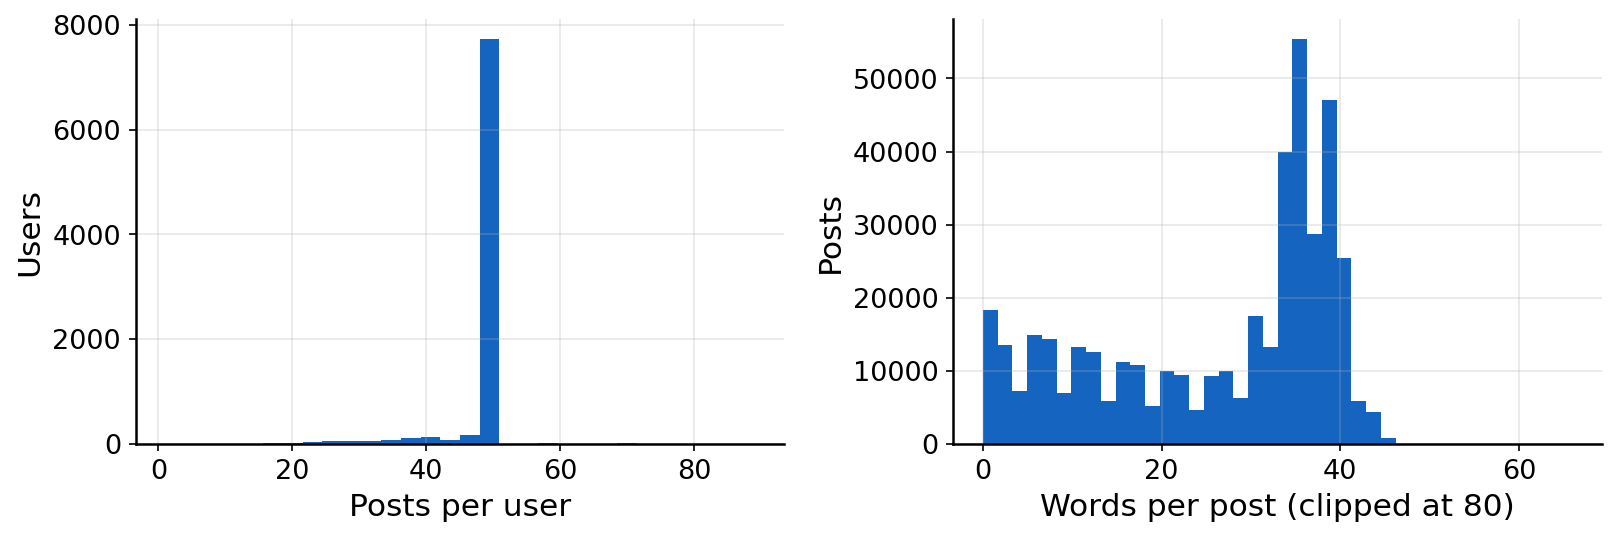

In [5]:
# ---- fig_mbti_post_stats: posts per user + words per post ----
n_posts = mbti["posts"].str.split(r"\|\|\|").str.len()
words = mbti["posts"].str.split(r"\|\|\|").explode().str.split().str.len()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.hist(n_posts, bins=30, color=BLUE)
ax1.set_xlabel("Posts per user")
ax1.set_ylabel("Users")
ax2.hist(words.clip(upper=80), bins=40, color=BLUE)
ax2.set_xlabel("Words per post (clipped at 80)")
ax2.set_ylabel("Posts")
save(fig, "fig_mbti_post_stats")

saved fig_user_activity -> figures/ + wut/tex/img/


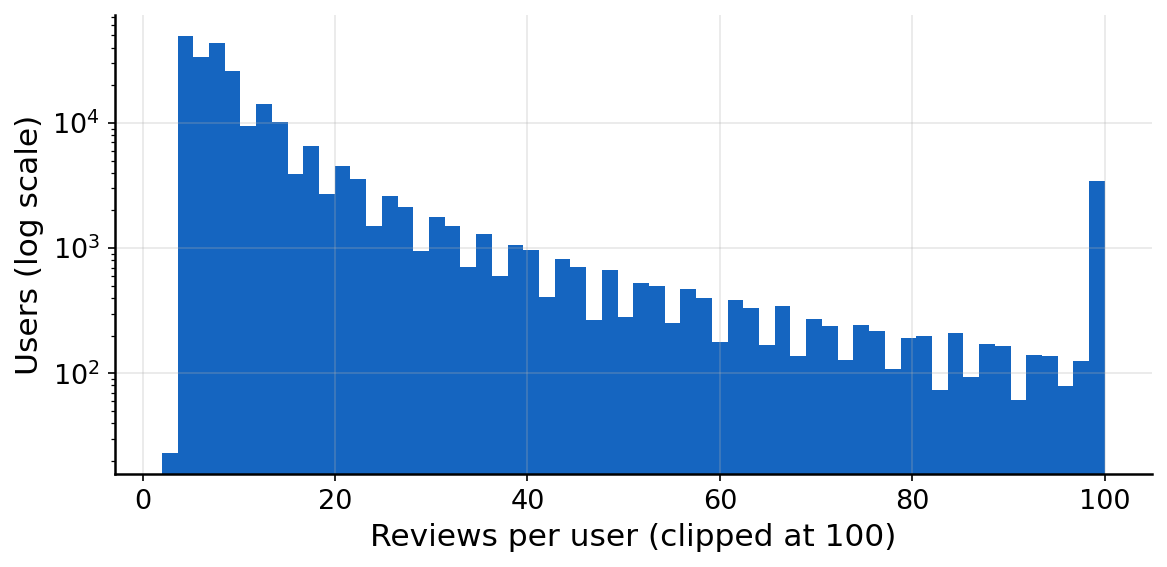

In [6]:
# ---- fig_user_activity: reviews per user (loads 3 big parquets, ~20 s) ----
parts = [pd.read_parquet(DATA_DIR / "processed" / f, columns=["user_id"])
         for f in ("train_reviews.parquet", "val_reviews.parquet",
                   "test_reviews.parquet")]
per_user = pd.concat(parts, ignore_index=True)["user_id"].value_counts()
del parts

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_user.clip(upper=100), bins=60, color=BLUE, log=True)
ax.set_xlabel("Reviews per user (clipped at 100)")
ax.set_ylabel("Users (log scale)")
save(fig, "fig_user_activity")

saved fig_venue_stars -> figures/ + wut/tex/img/


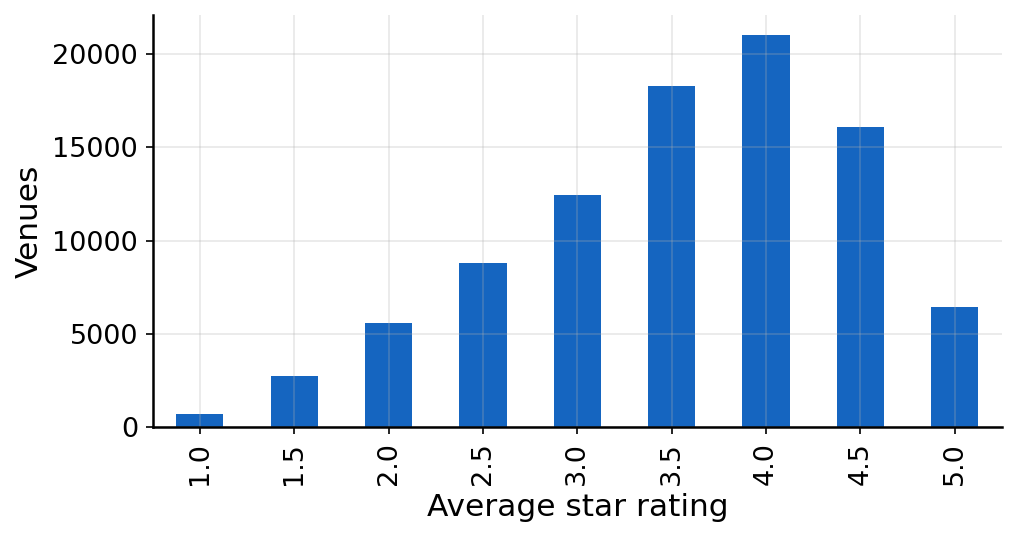

In [7]:
# ---- fig_venue_stars: venue star-rating distribution ----
fig, ax = plt.subplots(figsize=(7, 3.8))
biz["stars"].value_counts().sort_index().plot.bar(ax=ax, color=BLUE)
ax.set_xlabel("Average star rating")
ax.set_ylabel("Venues")
save(fig, "fig_venue_stars")

saved fig_top_categories -> figures/ + wut/tex/img/


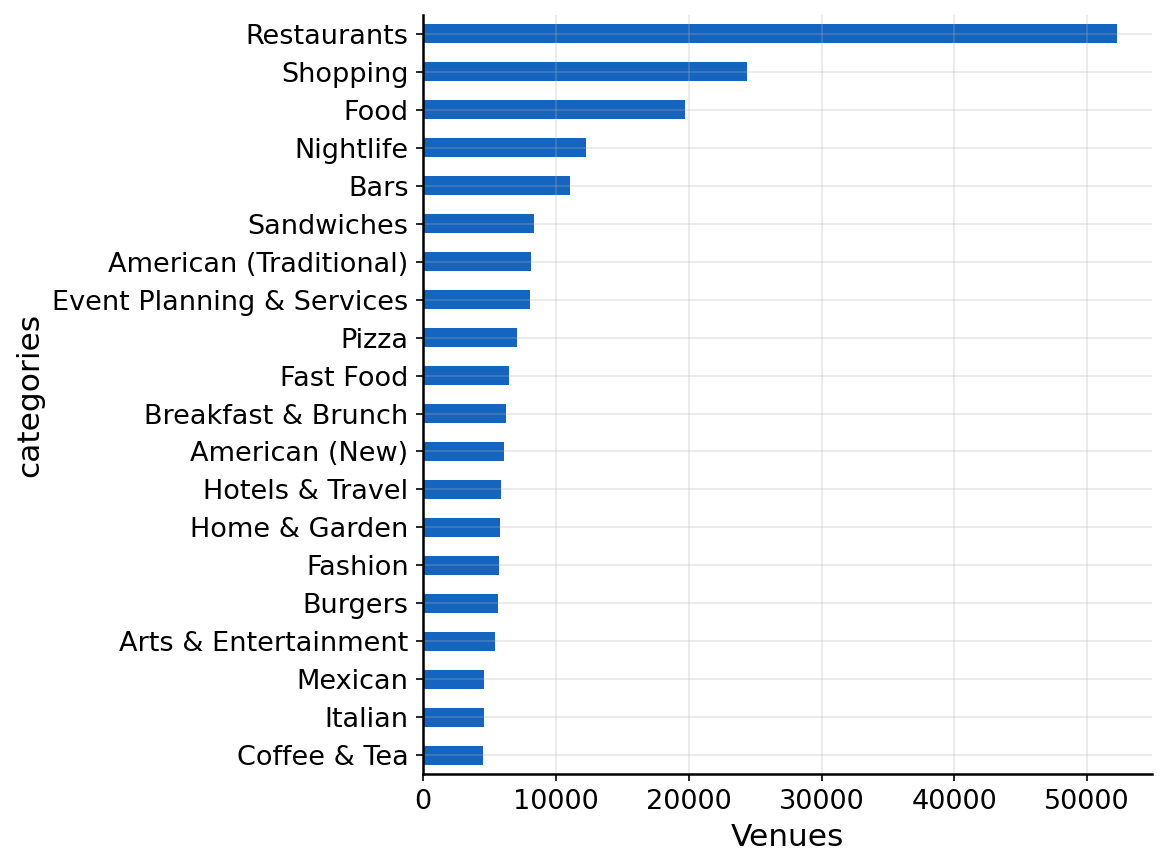

In [8]:
# ---- fig_top_categories: 20 most frequent venue categories ----
cats = (biz["categories"].dropna().str.split(", ").explode()
        .value_counts().head(20))
fig, ax = plt.subplots(figsize=(8, 6))
cats.iloc[::-1].plot.barh(ax=ax, color=BLUE)
ax.set_xlabel("Venues")
save(fig, "fig_top_categories")

## Chapter 4 - classifier figures

saved fig_training_curve -> figures/ + wut/tex/img/


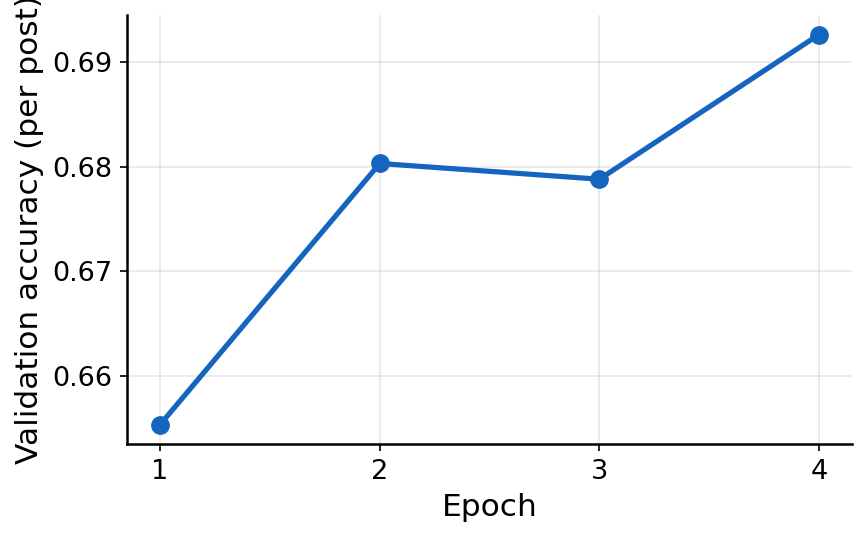

In [9]:
# ---- fig_training_curve: canonical run, per-post val accuracy ----
val_acc = [0.6554, 0.6803, 0.6788, 0.6926]   # measured, canonical laptop run
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(range(1, 5), val_acc, "o-", color=BLUE)
ax.set_xticks(range(1, 5))
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation accuracy (per post)")
save(fig, "fig_training_curve")

## Chapter 5 - result figures

saved fig_classifier_before_after -> figures/ + wut/tex/img/


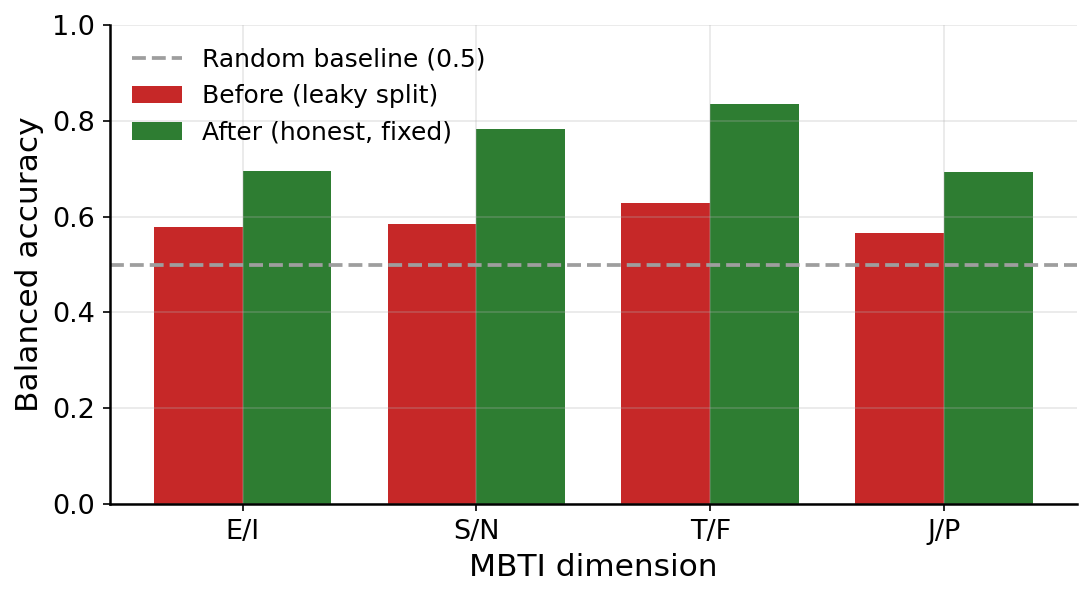

In [10]:
# ---- fig_classifier_before_after (5.1): red = leaky, green = honest ----
CLF_DIMS = ["E/I", "S/N", "T/F", "J/P"]
BEFORE = [0.579, 0.585, 0.629, 0.565]   # leaky post-level split
AFTER = [0.696, 0.782, 0.836, 0.693]    # user-disjoint, class-weighted

x = np.arange(len(CLF_DIMS))
w = 0.38
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(x - w/2, BEFORE, w, label="Before (leaky split)", color=BAD)
ax.bar(x + w/2, AFTER, w, label="After (honest, fixed)", color=GOOD)
ax.axhline(0.5, ls="--", lw=1.8, color=NEUT, label="Random baseline (0.5)")
ax.set_xticks(x)
ax.set_xticklabels(CLF_DIMS)
ax.set_xlabel("MBTI dimension")
ax.set_ylabel("Balanced accuracy")
ax.set_ylim(0, 1.0)
ax.legend(frameon=False, loc="upper left")
save(fig, "fig_classifier_before_after")

saved fig_backbone_ablation -> figures/ + wut/tex/img/


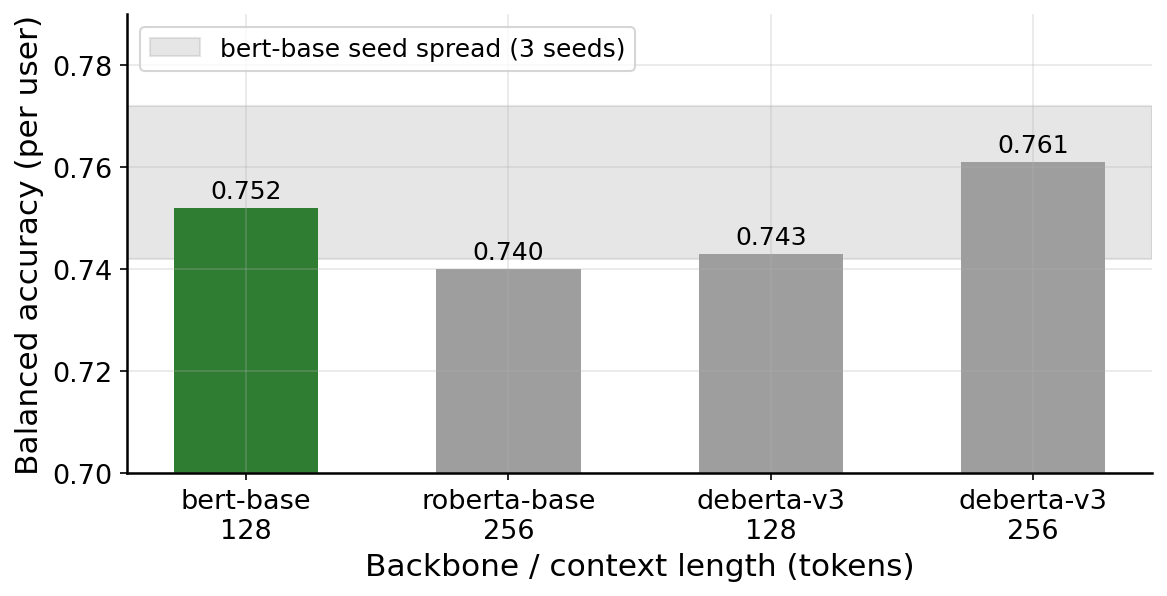

In [11]:
# ---- fig_backbone_ablation (5.2): canonical green, alternatives grey ----
names = ["bert-base\n128", "roberta-base\n256", "deberta-v3\n128",
         "deberta-v3\n256"]
vals = [0.752, 0.740, 0.743, 0.761]
SEED_LO, SEED_HI = 0.742, 0.772          # bert-base 3-seed spread

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.axhspan(SEED_LO, SEED_HI, color=GRAY, alpha=0.25,
           label="bert-base seed spread (3 seeds)")
ax.bar(names, vals, color=[GOOD, GRAY, GRAY, GRAY], width=0.55)
for i, v in enumerate(vals):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=12)
ax.set_ylim(0.70, 0.79)
ax.set_xlabel("Backbone / context length (tokens)")
ax.set_ylabel("Balanced accuracy (per user)")
ax.legend(loc="upper left")
save(fig, "fig_backbone_ablation")

saved fig_recommender_hitrate -> figures/ + wut/tex/img/


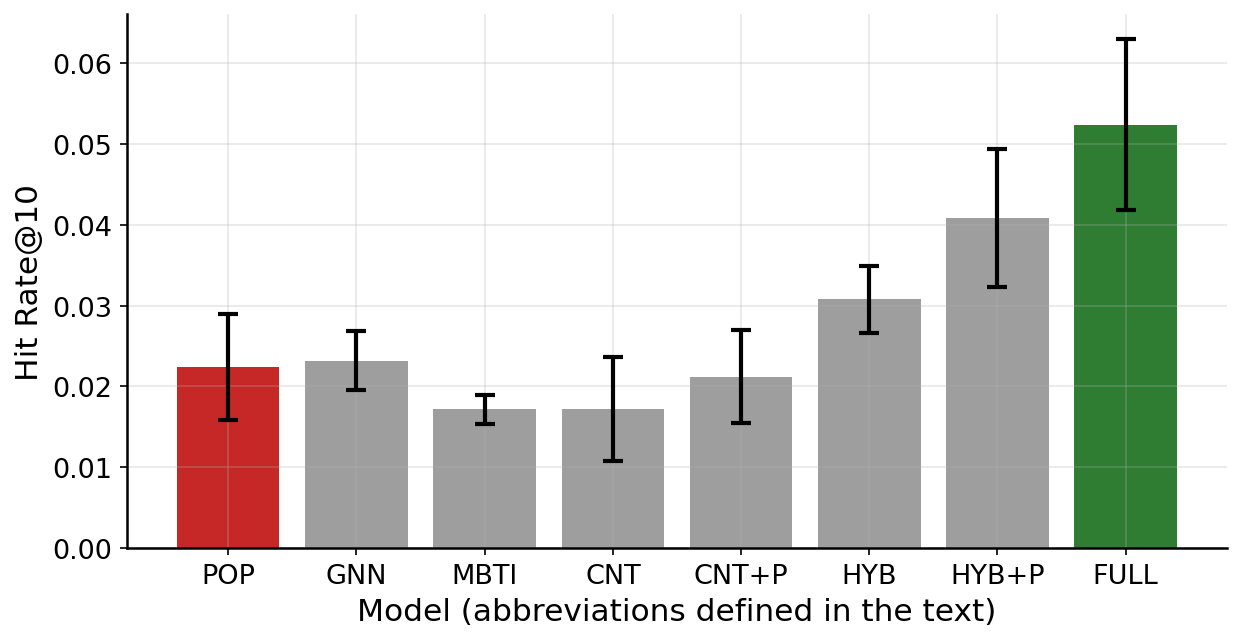

In [12]:
# ---- fig_recommender_hitrate (5.3): abbreviated x labels ----
ORDER = ["Popularity", "GNN-only", "MBTI-only", "KNN-only",
         "KNN+pop (no GNN)", "RRF-Hybrid (no pop)", "RRF-Hybrid (pop=0.01)",
         "Full (KNN+GNN+MBTI+pop)"]
ABBREV = ["POP", "GNN", "MBTI", "CNT", "CNT+P", "HYB", "HYB+P", "FULL"]

sub = agg[agg["K"] == 10].set_index("Model").reindex(ORDER)
x = np.arange(len(ORDER))
colors = [BAD] + [NEUT] * (len(ORDER) - 2) + [GOOD]
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(x, sub["Hit Rate@K_mean"], yerr=sub["Hit Rate@K_std"], capsize=5,
       error_kw={"elinewidth": 2, "capthick": 2}, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(ABBREV)
ax.set_xlabel("Model (abbreviations defined in the text)")
ax.set_ylabel("Hit Rate@10")
save(fig, "fig_recommender_hitrate")

saved fig_k_sensitivity -> figures/ + wut/tex/img/


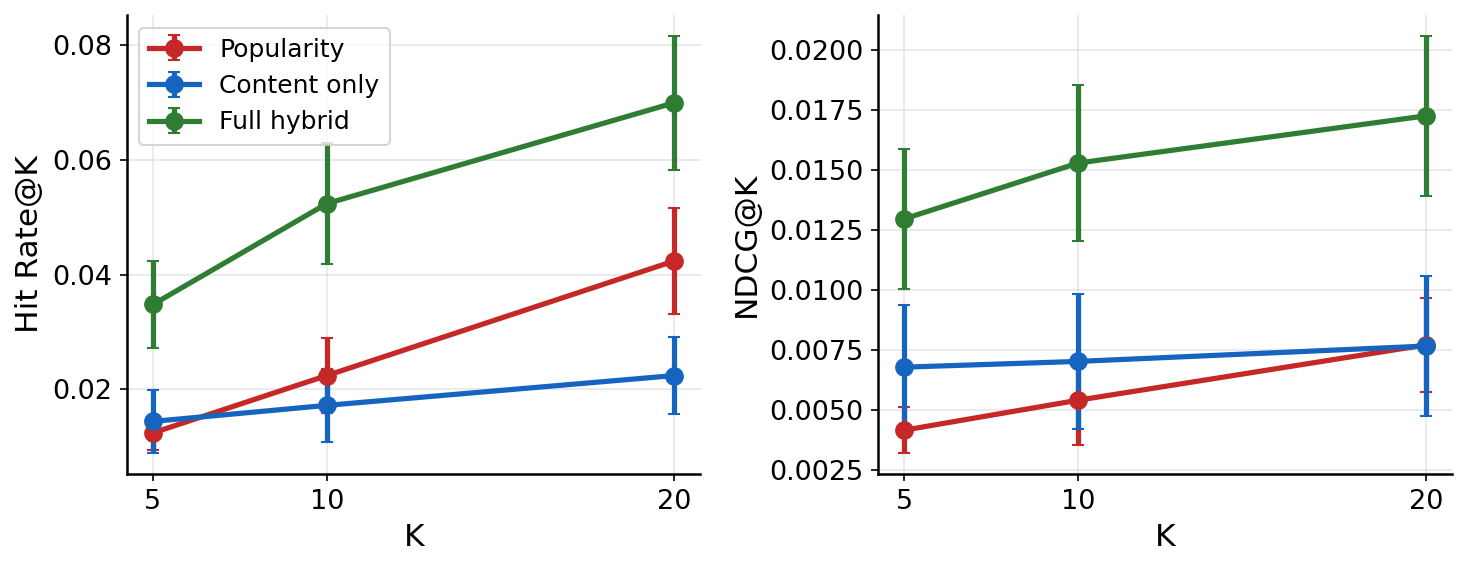

In [13]:
# ---- fig_k_sensitivity (5.4): metric vs K for three key models ----
models = {"Popularity": BAD, "KNN-only": BLUE,
          "Full (KNN+GNN+MBTI+pop)": GOOD}
pretty = {"Popularity": "Popularity", "KNN-only": "Content only",
          "Full (KNN+GNN+MBTI+pop)": "Full hybrid"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for m, c in models.items():
    s = agg[agg["Model"] == m].sort_values("K")
    ax1.errorbar(s["K"], s["Hit Rate@K_mean"], yerr=s["Hit Rate@K_std"],
                 fmt="o-", color=c, label=pretty[m], capsize=3)
    ax2.errorbar(s["K"], s["NDCG@K_mean"], yerr=s["NDCG@K_std"],
                 fmt="o-", color=c, label=pretty[m], capsize=3)
for ax, name in ((ax1, "Hit Rate@K"), (ax2, "NDCG@K")):
    ax.set_xticks([5, 10, 20])
    ax.set_xlabel("K")
    ax.set_ylabel(name)
ax1.legend()
save(fig, "fig_k_sensitivity")

saved fig_ablation_ndcg -> figures/ + wut/tex/img/


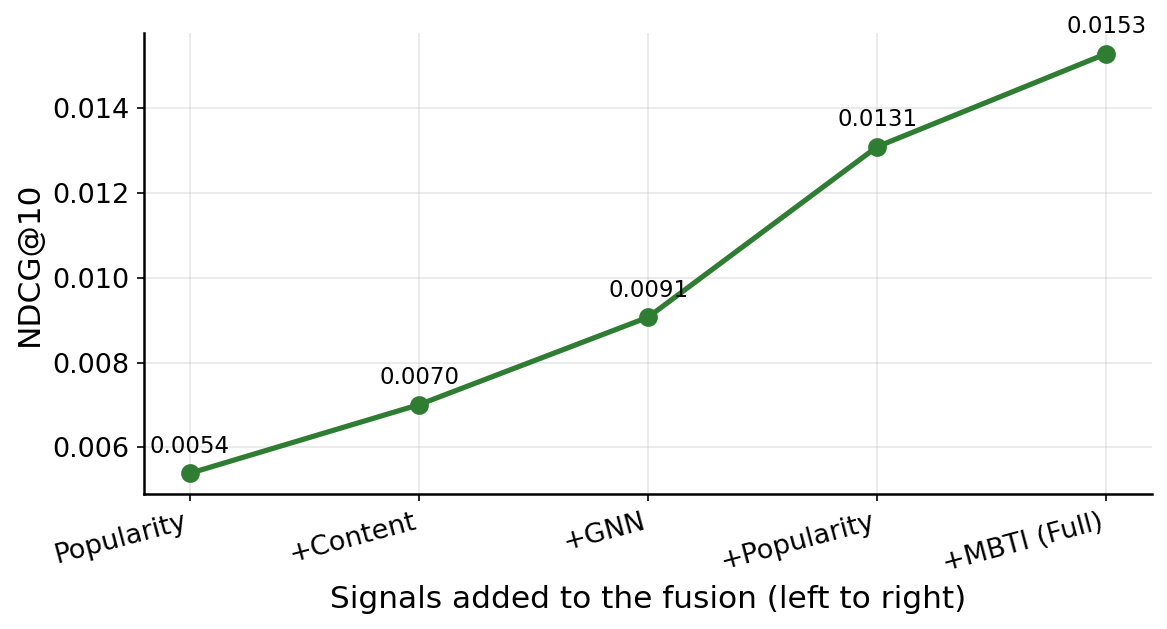

In [14]:
# ---- fig_ablation_ndcg (5.5): incremental signal build-up ----
chain = ["Popularity", "KNN-only", "RRF-Hybrid (no pop)",
         "RRF-Hybrid (pop=0.01)", "Full (KNN+GNN+MBTI+pop)"]
chain_lbl = ["Popularity", "+Content", "+GNN", "+Popularity", "+MBTI (Full)"]

s = agg[agg["K"] == 10].set_index("Model")
ndcg = [s.loc[m, "NDCG@K_mean"] for m in chain]
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(range(len(chain)), ndcg, "-o", color=GOOD)
ax.set_xticks(range(len(chain)))
ax.set_xticklabels(chain_lbl, rotation=15, ha="right")
ax.set_xlabel("Signals added to the fusion (left to right)")
ax.set_ylabel("NDCG@10")
for i, v in enumerate(ndcg):
    ax.annotate(f"{v:.4f}", (i, v), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=11)
save(fig, "fig_ablation_ndcg")

saved fig_seed_variance -> figures/ + wut/tex/img/


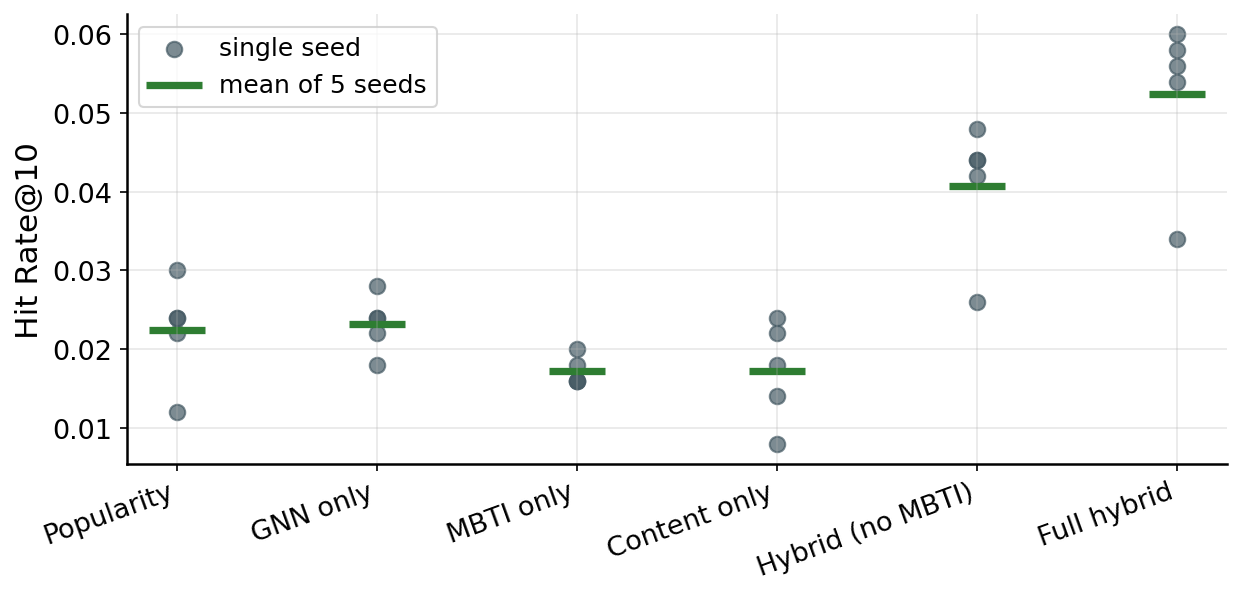

In [15]:
# ---- fig_seed_variance (5.6): per-seed spread of Hit Rate@10 ----
order = ["Popularity", "GNN-only", "MBTI-only", "KNN-only",
         "RRF-Hybrid (pop=0.01)", "Full (KNN+GNN+MBTI+pop)"]
pretty = ["Popularity", "GNN only", "MBTI only", "Content only",
          "Hybrid (no MBTI)", "Full hybrid"]

k10 = per_seed[per_seed["K"] == 10]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
for i, m in enumerate(order):
    vals = k10[k10["Model"] == m]["Hit Rate@K"]
    ax.scatter([i] * len(vals), vals, color="#455a64", alpha=0.7, s=55,
               label="single seed" if i == 0 else None)
    ax.scatter([i], [vals.mean()], color=GOOD, marker="_", s=700, lw=3.5,
               label="mean of 5 seeds" if i == 0 else None)
ax.set_xticks(range(len(order)), pretty, rotation=20, ha="right")
ax.set_ylabel("Hit Rate@10")
ax.legend(loc="upper left")
save(fig, "fig_seed_variance")

## Chapter 10 - planner extension

saved fig_faithfulness -> figures/ + wut/tex/img/


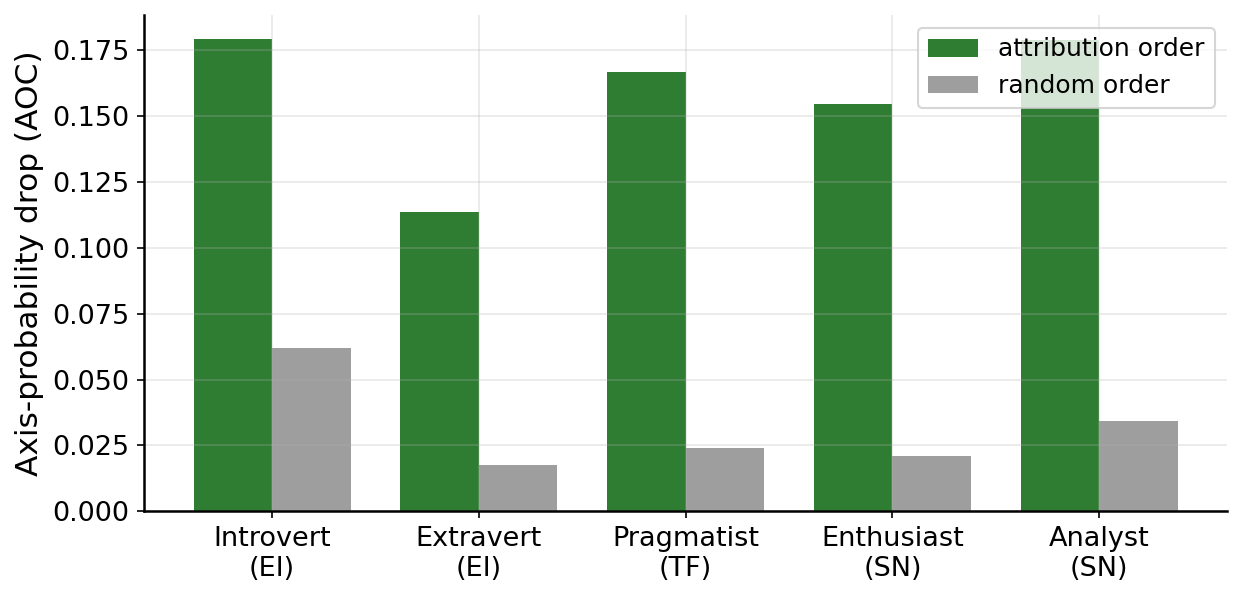

In [16]:
# ---- fig_faithfulness: deletion test, attribution vs random ----
labels = ["Introvert", "Extravert", "Pragmatist", "Enthusiast", "Analyst"]
x = np.arange(len(faith))
w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.bar(x - w/2, faith["aoc_attribution"], w, color=GOOD,
       label="attribution order")
ax.bar(x + w/2, faith["aoc_random"], w, color=NEUT, label="random order")
ax.set_xticks(x, [f"{l}\n({a})" for l, a in zip(labels, faith["axis"])])
ax.set_ylabel("Axis-probability drop (AOC)")
ax.legend()
save(fig, "fig_faithfulness")